# MLP Tuning Notebook  
**for Bamboo**  
This notebook tunes a single model on a fixed feature tier and a consistent hold-out split, saving the **best estimator** and **CV results** under `./models` and `./results`.

**Assumptions**
- Data file: `bamboo.csv` in the working directory
- Targets: `["BS","MOE","EC"]`
- Feature Tiers are defined inline; change `SELECTED_TIER` as needed.
- Repeated K-Fold CV for robust estimates.

> Uses the same `RSEED` and **the same hold-out split** for comparability across models.



### **Loading**

In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# 0. Imports & global settings
# ──────────────────────────────────────────────────────────────────────────────
import os, warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    explained_variance_score
)

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RSEED = 0
np.random.seed(RSEED)

Path("models_bamboo").mkdir(exist_ok=True)
Path("results_bamboo").mkdir(exist_ok=True)


### **DATA**  
  TIER_SMART was used in the thesis because it produced the highest scores in the stat metrics.

In [ ]:

# ──────────────────────────────────────────────────────────────────────────────
# 1. Data & tier definitions
# ──────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("bamboo.csv")
#assert set(['d','thk','m','rho','o_taper','i_taper','oval','e','mc','mom','stiff','moe','BS','UF','EC']).issubset(df.columns)

# %%
# 2. Targets & Tiers (BS, MOE, EC)
TARGETS = ['BS', 'moe', 'EC']

TIERS = {
    "TIER0_geom": ['d', 'thk', 'm', 'rho'],
    "TIER1_shape": ['d', 'thk', 'm', 'rho', 'o_taper', 'i_taper', 'oval', 'e'],
    "TIER_FULL": ['d', 'thk', 'm', 'rho', 'o_taper', 'i_taper', 'oval', 'e', 'mc', 'mom', 'stiff', 'UF'],
    "TIER_SMART": [ 'd','thk','rho', 'UF', 'm', 'mom', 'stiff', 'e', 'mc']  # Remove weak or redundant vars
}
SELECTED_TIER = "TIER_SMART" 
feats = TIERS[SELECTED_TIER]

# Integrity check
miss = [c for c in feats + TARGETS if c not in df.columns]
if miss:
    raise KeyError(f"Missing columns in data file: {miss}")

# Consistent train/test split for comparability
def holdout_split(df, feats, targets, tst=0.30, seed=RSEED):
    X = df[feats]
    y = df[targets]
    return train_test_split(X, y, test_size=tst, random_state=seed)

Xtr, Xte, ytr, yte = holdout_split(df, feats, TARGETS)
CV = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RSEED)


### **Estimator & Search Space**

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 2. Metrics helper
# ──────────────────────────────────────────────────────────────────────────────
def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def compute_metrics(y_true_df, y_pred_np):
    rows, rmses = [], []
    for i, tgt in enumerate(TARGETS):
        yt = y_true_df[tgt].to_numpy()
        yp = y_pred_np[:, i]
        mse  = mean_squared_error(yt, yp)
        rmse = float(np.sqrt(mse))
        rows.append({
            "Target": tgt,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mean_absolute_error(yt, yp),
            "sMAPE": smape(yt, yp),
            "R2":  r2_score(yt, yp),
            "EVS": explained_variance_score(yt, yp)
        })
        rmses.append(rmse)
    return pd.DataFrame(rows), float(np.mean(rmses))


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 3. Estimator, search space, and tag
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator, RegressorMixin

ARCH = "MLP"
N_ITER = 200
tag = f"{SELECTED_TIER}__{ARCH}"

class MLPProxy(BaseEstimator, RegressorMixin):
    """
    A small wrapper that turns scalar knobs (units1/2/3) into hidden_layer_sizes tuple.
    This avoids skopt's issue with tuple-valued Categorical parameters.
    """
    def __init__(self,
                 units1=128, units2=0, units3=0,
                 activation="relu",
                 alpha=1e-4,
                 learning_rate_init=1e-3,
                 batch_size=64,
                 beta_1=0.9, beta_2=0.999,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=25, max_iter=1000,
                 solver="adam", shuffle=True,
                 random_state=RSEED):
        self.units1 = units1
        self.units2 = units2
        self.units3 = units3
        self.activation = activation
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.max_iter = max_iter
        self.solver = solver
        self.shuffle = shuffle
        self.random_state = random_state

    def _build(self):
        layers = tuple([int(u) for u in (self.units1, self.units2, self.units3) if int(u) > 0])
        if not layers:
            layers = (64,) 
        return MLPRegressor(
            hidden_layer_sizes=layers,
            activation=self.activation,
            alpha=self.alpha,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            beta_1=self.beta_1, beta_2=self.beta_2,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            max_iter=self.max_iter,
            solver=self.solver,
            shuffle=self.shuffle,
            random_state=self.random_state
        )

    def fit(self, X, y):
        self._model = self._build()
        return self._model.fit(X, y)

    def predict(self, X):
        return self._model.predict(X)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MultiOutputRegressor(MLPProxy()))
])

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

space = {
    "regressor__estimator__units1": Integer(64, 300),   
    "regressor__estimator__units2": Integer(0, 200),    # 0 means "no second layer"
    "regressor__estimator__units3": Integer(0, 150),    # 0 means "no third layer"
    "regressor__estimator__activation": Categorical(["relu","tanh"]),
    "regressor__estimator__alpha": Real(1e-6, 1e-1, prior="log-uniform"),
    "regressor__estimator__learning_rate_init": Real(1e-4, 3e-3, prior="log-uniform"),
    "regressor__estimator__batch_size": Categorical([32, 64, 128]),
    "regressor__estimator__beta_1": Real(0.85, 0.95),
    "regressor__estimator__beta_2": Real(0.990, 0.999)
}

search = BayesSearchCV(
    pipe, space,
    n_iter=N_ITER,
    cv=CV,
    scoring="neg_root_mean_squared_error",
    random_state=RSEED,
    n_jobs=-1,
    refit=True,
    verbose=0
)


### **Training and Evaluation**

Fitting BayesSearchCV for MLP on TIER_SMART features…
Best params: OrderedDict([('regressor__estimator__activation', 'relu'), ('regressor__estimator__alpha', 1e-06), ('regressor__estimator__batch_size', 32), ('regressor__estimator__beta_1', 0.85), ('regressor__estimator__beta_2', 0.99), ('regressor__estimator__learning_rate_init', 0.003), ('regressor__estimator__units1', 300), ('regressor__estimator__units2', 200), ('regressor__estimator__units3', 94)])


(  Target            MSE        RMSE         MAE     sMAPE        R2       EVS  \
 0     BS      17.624172    4.198115    2.593787  0.032172  0.961215  0.961227   
 1    moe  680623.111242  824.998855  636.080992  0.036121  0.959054  0.959054   
 2     EC       0.002980    0.054587    0.040023  0.209239  0.976279  0.977848   
 
   Arch        Tier         ModelTag  Composite_RMSE  
 0  MLP  TIER_SMART  TIER_SMART__MLP      276.417186  
 1  MLP  TIER_SMART  TIER_SMART__MLP      276.417186  
 2  MLP  TIER_SMART  TIER_SMART__MLP      276.417186  ,
 276.4171860045835)

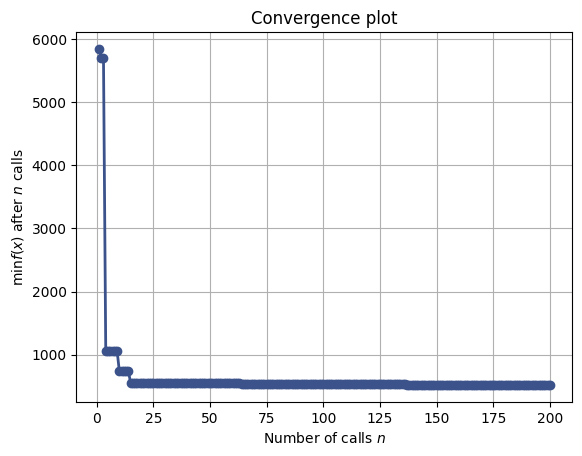

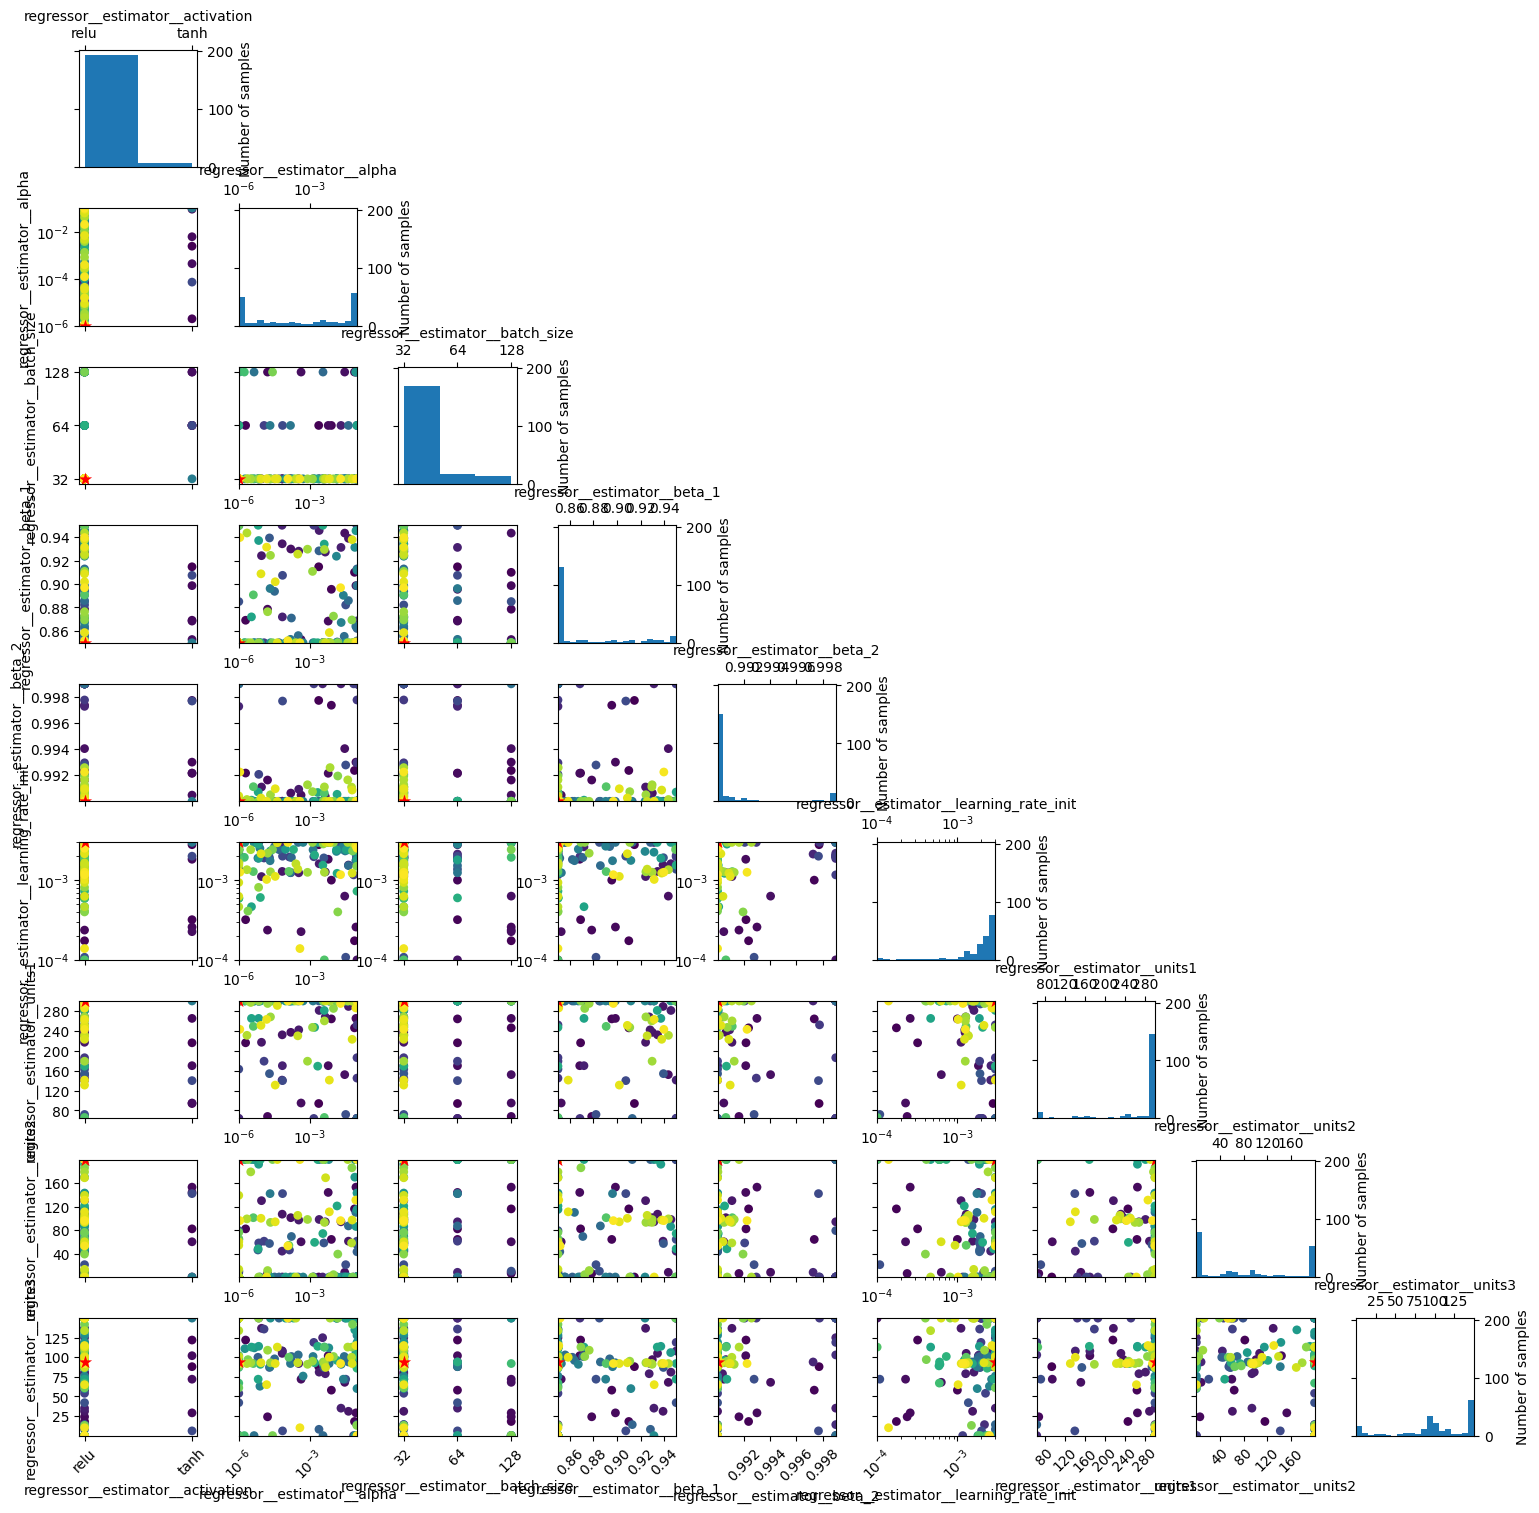

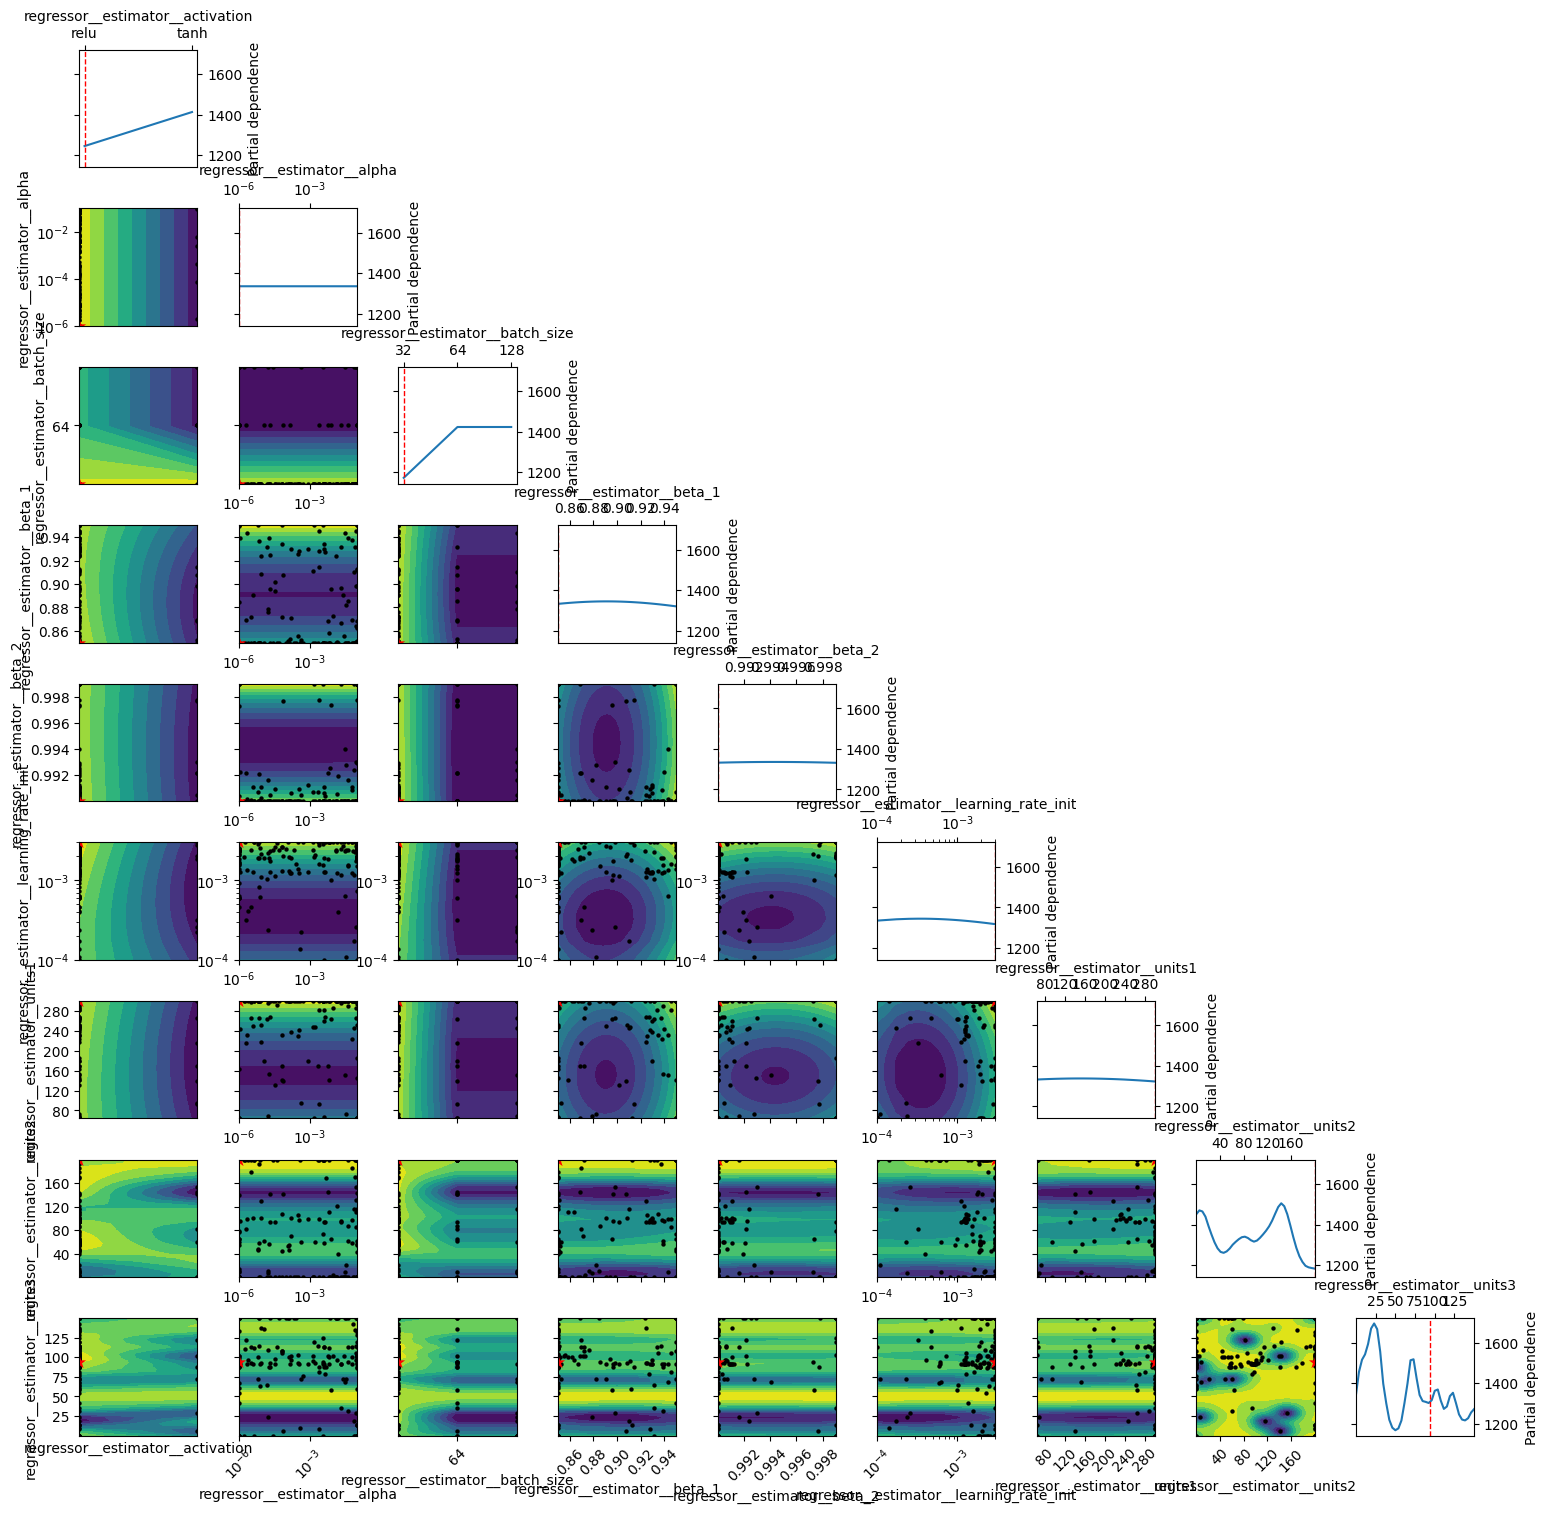

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 4. Fit, convergence plot, evaluate, and save
# ──────────────────────────────────────────────────────────────────────────────
print("Fitting BayesSearchCV for MLP on", SELECTED_TIER, "features…")
search.fit(Xtr, ytr)
best_model = search.best_estimator_
print("Best params:", search.best_params_)

# Error vs iteration (from CV results)
cv = pd.DataFrame(search.cv_results_)
cv["iter"] = range(1, len(cv)+1)
cv["rmse"] = -cv["mean_test_score"]
cv["best_rmse_so_far"] = cv["rmse"].cummin()

import matplotlib.pyplot as plt
plt.plot(cv["iter"], cv["rmse"], label="RMSE per iter")
plt.plot(cv["iter"], cv["best_rmse_so_far"], label="Best so far")
plt.xlabel("Bayes iteration"); plt.ylabel("CV RMSE (lower is better)")
plt.title(f"Convergence trace — {tag}")
plt.legend(); plt.tight_layout()
plt.savefig(f"results/{tag}_incumbent_trace.png", dpi=200); plt.close()


try:
    from skopt.plots import plot_convergence, plot_evaluations, plot_objective
    opt_res = search.optimizer_results_[0]
    plot_convergence(opt_res).figure.savefig(f"results/{tag}_convergence.png", dpi=200, bbox_inches="tight")
    plot_evaluations(opt_res).figure.savefig(f"results/{tag}_hyperparam_evaluations.png", dpi=200, bbox_inches="tight")
    plot_objective(opt_res).figure.savefig(f"results/{tag}_hyperparam_objective.png", dpi=200, bbox_inches="tight")
except Exception as e:
    print("skopt diagnostics unavailable on this version; skipping.", e)

# Evaluate on the fixed test split
y_pred = best_model.predict(Xte)
per_target, comp_rmse = compute_metrics(yte, y_pred)

# Save artifacts
joblib.dump(best_model, f"models/{tag}.pkl")
per_target["Arch"] = ARCH
per_target["Tier"] = SELECTED_TIER
per_target["ModelTag"] = tag
per_target["Composite_RMSE"] = comp_rmse
per_target.to_csv(f"results/{tag}_metrics.csv", index=False)
pd.DataFrame(search.cv_results_).to_csv(f"results/{tag}_cv_results.csv", index=False)

# Show summary in notebook output
per_target, comp_rmse


In [ ]:
# Make a portable copy (no custom classes) before saving
portable = best_model
reg = portable.named_steps["regressor"]
for i, est in enumerate(reg.estimators_):
    if hasattr(est, "_model"):  # unwrap MLPProxy
        reg.estimators_[i] = est._model

# Save portable
joblib.dump(portable, f"models/{tag}.pkl")  # overwrites with pure sklearn


In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# 5. (Optional) Permutation importance per target on the fixed test split
# ──────────────────────────────────────────────────────────────────────────────
# MLP doesn't have native feature importance.
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

try:
    best_params = search.best_params_
    # Map multioutput param names to a single-target pipeline's param names
    mapped = {k.replace("regressor__estimator__", "regressor__"): v for k, v in best_params.items()}
    for tgt in TARGETS:
        single = Pipeline([("scaler", StandardScaler()), ("regressor", MLPRegressor(random_state=RSEED, max_iter=1000))])
        single.set_params(**mapped)
        single.fit(Xtr, ytr[tgt])
        r = permutation_importance(single, Xte, yte[tgt],
                                   scoring="neg_root_mean_squared_error",
                                   n_repeats=10, random_state=RSEED)
        imp = pd.Series(r.importances_mean, index=feats).sort_values(ascending=False)
        imp.to_csv(f"results/{tag}_permimp_{tgt}.csv")
        plt.figure(); imp.head(20).plot(kind="barh"); plt.gca().invert_yaxis()
        plt.title(f"{tag}: permutation importance — {tgt}")
        plt.tight_layout(); plt.savefig(f"results/{tag}_permimp_{tgt}.png", dpi=200); plt.close()
except Exception as e:
    print("Permutation importance step skipped:", e)


Permutation importance step skipped: Invalid parameter 'units1' for estimator MLPRegressor(activation='tanh', alpha=1e-06, batch_size=32,
             beta_1=0.8683157877569334, beta_2=0.99, learning_rate_init=0.003,
             max_iter=1000, random_state=0). Valid parameters are: ['activation', 'alpha', 'batch_size', 'beta_1', 'beta_2', 'early_stopping', 'epsilon', 'hidden_layer_sizes', 'learning_rate', 'learning_rate_init', 'max_fun', 'max_iter', 'momentum', 'n_iter_no_change', 'nesterovs_momentum', 'power_t', 'random_state', 'shuffle', 'solver', 'tol', 'validation_fraction', 'verbose', 'warm_start'].
